In [ ]:
from typing import Any, Dict, List, Optional
import math
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from hard_tack.cpmi_reward_final import CPMIEnsembleReward, PROMPT_TEMPLATES
from hard_tack.cpmi_reward_simple import CPMISimpleReward, PROMPT_TEMPLATES

def load_qwen_rewarder(
    model_name_or_path: str,
    *,
    device: str = "cuda",
    torch_dtype: torch.dtype = torch.bfloat16,
    trust_remote_code: bool = True,
    **model_kwargs: Any,
) -> Dict[str, Any]:
    """
    Returns {"model", "tokenizer", "rewarder"} ready for CPMI-style scoring.
    """
    tokenizer = AutoTokenizer.from_pretrained(
        model_name_or_path,
        trust_remote_code=trust_remote_code,
    )

    defaults = dict(torch_dtype=torch_dtype, trust_remote_code=trust_remote_code)
    defaults.update(model_kwargs)
    if device == "auto" and "device_map" not in defaults:
        defaults["device_map"] = "auto"

    model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path,
        **defaults,
    )
    if device != "auto":
        model.to(device)
    model.eval()

    rewarder = CPMIEnsembleReward(model=model, tokenizer=tokenizer)
    rewarder._ensure_pad_token()  # keep padding sane for batching

    return {"model": model, "tokenizer": tokenizer, "rewarder": rewarder}

def gather_negative_candidates(rewarder: CPMIEnsembleReward, question: str, steps: List[str], gold_answer: str, *,
    max_candidates: int = 8, n_sample: int = 6, sample_kwargs: Optional[Dict[str, Any]] = None,) -> Dict[str, List[str]]:
    sample_kwargs = sample_kwargs or {}
    gold_norm = rewarder._norm_ans_text(gold_answer)
    wrapped_gold = rewarder._wrap_ans(gold_norm)

    model_samples = rewarder._sample_model_negatives(
        question,
        steps,
        gold_norm,
        n=n_sample,
        **sample_kwargs,
    )
    heuristics = rewarder._heuristic_negatives(gold_norm, max_h=max_candidates)

    chosen: List[str] = []
    seen = {wrapped_gold}
    for cand in model_samples + heuristics:
        if cand not in seen and rewarder._is_valid_wrapped(cand):
            chosen.append(cand)
            seen.add(cand)
        if len(chosen) >= max_candidates:
            break

    return {
        "model_samples": model_samples,
        "heuristics": heuristics,
        "final": chosen,
    }

def compute_step_rewards(
    rewarder: CPMIEnsembleReward,
    question: str,
    steps: List[str],
    gold_answer: str,
    *,
    template_ids: Optional[List[int]] = None,
    neg_targets: Optional[List[str]] = None,
    batch_size: int = 6,
    normalize: bool = True,
) -> Dict[str, Any]:
    """
    Computes CMI / marginal / LOO rewards step-by-step.
    """
    template_ids = template_ids or list(range(len(PROMPT_TEMPLATES)))
    answer_target = rewarder._format_answer_target(gold_answer)
    neg_targets = neg_targets or []

    cmi_vals, _ = rewarder.compute_step_contrastive_cmi_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )
    marginal_vals, _ = rewarder.compute_step_contrastive_marginal_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )
    loo_vals, _ = rewarder.compute_step_contrastive_loo_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )

    table = []
    for idx, step in enumerate(steps):
        table.append(
            {
                "step_idx": idx + 1,
                "step_text": step.strip(),
                "reward_cmi": cmi_vals[idx],
                "reward_marginal": marginal_vals[idx],
                "reward_loo": loo_vals[idx],
            }
        )

    return {
        "step_rewards": table,
        "negatives": neg_targets,
        "templates": template_ids,
    }

def list_step_contexts(
    rewarder: CPMIEnsembleReward,
    question: str,
    steps: List[str],
    template_id: int = 0,
) -> Dict[str, List[str]]:
    base = rewarder.build_prompt(question, template_id) + "\n"
    prefixes = rewarder._prefixes_from_base_and_steps(base, steps)
    return {
        "base_prompt": prefixes[0],
        "after_each_step": prefixes[1:],  # aligned with step indices
        "full_prompt": prefixes[-1],
    }

def trace_target_logits(rewarder: CPMIEnsembleReward, prompt: str, target: str, *, top_k: int = 5,) -> List[Dict[str, Any]]:
    """
    Teacher-forced logit trace for the target suffix (token, logprob, and top-k competitors).
    """
    tokenizer = rewarder.tokenizer
    model = rewarder.model
    device = rewarder.device

    with torch.no_grad():
        full = prompt + target
        encoded = tokenizer(full, return_tensors="pt", add_special_tokens=True)
        encoded = {k: v.to(device) for k, v in encoded.items()}
        logits = model(**encoded).logits.float()

    tgt_ids = tokenizer(target, add_special_tokens=False)["input_ids"]
    full_ids = encoded["input_ids"][0].tolist()
    start = rewarder._find_suffix_start(full_ids, tgt_ids)
    if start < 0:
        start = len(full_ids) - len(tgt_ids)

    offset = max(start - 1, 0)
    logits_shifted = logits[:, :-1, :]
    eff_len = min(len(tgt_ids), logits_shifted.shape[1] - offset)
    logprobs = torch.log_softmax(logits_shifted[0, offset : offset + eff_len, :], dim=-1)

    trace: List[Dict[str, Any]] = []
    for i in range(eff_len):
        token_id = tgt_ids[i]
        token_str = tokenizer.convert_ids_to_tokens([token_id])[0]
        logprob = float(logprobs[i, token_id].item())
        prob = math.exp(logprob)

        current_logits = logits_shifted[0, offset + i]
        top_vals, top_ids = torch.topk(current_logits, k=top_k)
        top_tokens = tokenizer.convert_ids_to_tokens(top_ids.tolist())
        top_probs = torch.softmax(top_vals, dim=0).tolist()

        trace.append(
            {
                "position": i,
                "target_token": token_str,
                "target_id": token_id,
                "logprob": logprob,
                "prob": prob,
                "top_k_tokens": top_tokens,
                "top_k_probs": top_probs,
            }
        )
    return trace

from typing import Any, Dict, List, Optional
def debug_cmi_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-CMI path."""
    entries: List[Dict[str, Any]] = []
    prompt = base
    gold_prev = rewarder._LP_cached_mean(prompt, gold_target) if normalize else rewarder._LP_cached_sum(prompt, gold_target)
    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        prompt_with = prompt + raw_step.rstrip().rstrip("\n") + "\n"
        gold_with = rewarder._LP_cached_mean(prompt_with, gold_target) if normalize else rewarder._LP_cached_sum(prompt_with, gold_target)
        gold_delta = gold_with - gold_prev

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_prev = rewarder._LP_cached_mean(prompt, neg) if normalize else rewarder._LP_cached_sum(prompt, neg)
                n_with = rewarder._LP_cached_mean(prompt_with, neg) if normalize else rewarder._LP_cached_sum(prompt_with, neg)
                diff = n_with - n_prev
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_prev,
            "gold_next": gold_with,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)

        prompt = prompt_with
        gold_prev = gold_with
    return entries

def debug_marginal_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-marginal path."""
    entries: List[Dict[str, Any]] = []
    gold_base = rewarder._LP_cached_mean(base, gold_target) if normalize else rewarder._LP_cached_sum(base, gold_target)

    neg_base_cache: Dict[str, float] = {}
    if neg_targets:
        for neg in neg_targets:
            neg_base_cache[neg] = rewarder._LP_cached_mean(base, neg) if normalize else rewarder._LP_cached_sum(base, neg)

    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        with_i = base + raw_step.rstrip().rstrip("\n") + "\n"
        gold_with = rewarder._LP_cached_mean(with_i, gold_target) if normalize else rewarder._LP_cached_sum(with_i, gold_target)
        gold_delta = gold_with - gold_base

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_base = neg_base_cache[neg]
                n_with = rewarder._LP_cached_mean(with_i, neg) if normalize else rewarder._LP_cached_sum(with_i, neg)
                diff = n_with - n_base
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_base,
            "gold_next": gold_with,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)
    return entries

def debug_loo_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-LOO path."""
    entries: List[Dict[str, Any]] = []
    with_all = base + "".join(step.rstrip().rstrip("\n") + "\n" for step in steps)
    gold_all = rewarder._LP_cached_mean(with_all, gold_target) if normalize else rewarder._LP_cached_sum(with_all, gold_target)

    neg_all_cache: Dict[str, float] = {}
    if neg_targets:
        for neg in neg_targets:
            neg_all_cache[neg] = rewarder._LP_cached_mean(with_all, neg) if normalize else rewarder._LP_cached_sum(with_all, neg)

    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        without_i = base + "".join(steps[j].rstrip().rstrip("\n") + "\n" for j in range(len(steps)) if j != idx)
        gold_without = rewarder._LP_cached_mean(without_i, gold_target) if normalize else rewarder._LP_cached_sum(without_i, gold_target)
        gold_delta = gold_all - gold_without

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_all = neg_all_cache[neg]
                n_without = rewarder._LP_cached_mean(without_i, neg) if normalize else rewarder._LP_cached_sum(without_i, neg)
                diff = n_all - n_without
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_without,
            "gold_next": gold_all,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)
    return entries

def debug_step_reward_breakdown_naive(
    rewarder,
    example: Dict[str, Any],
    *,
    template_ids: Optional[List[int]] = None,
    neg_targets: Optional[List[str]] = None,
    normalize: bool = True,
    include_per_template: bool = True,
    include_per_neg: bool = False,
) -> Dict[str, Any]:
    """
    Full breakdown (CMI, marginal, LOO) for a single parsed record.
    `example` is what `rewarder.parse_math_shepherd_record` returns.
    """
    steps = example["steps"]
    question = example["question"]
    gold_answer = example["gold_answer"]

    template_ids = template_ids or [0, 1, 2, 3]
    neg_targets = neg_targets or []
    gold_target = rewarder._format_answer_target(gold_answer)
    S = len(steps)

    helpers = {
        "cmi": debug_cmi_from_base_naive,
        "marginal": debug_marginal_from_base_naive,
        "loo": debug_loo_from_base_naive,
    }

    def aggregate(per_template: Dict[int, List[Dict[str, Any]]]) -> List[Dict[str, Any]]:
        gold_acc = [0.0] * S
        neg_acc = [0.0] * S
        reward_acc = [0.0] * S
        for tmpl_entries in per_template.values():
            for i, ent in enumerate(tmpl_entries):
                gold_acc[i] += ent["gold_term"]
                neg_acc[i] += ent["neg_term"]
                reward_acc[i] += ent["reward"]
        denom = float(len(per_template)) if per_template else 1.0
        summary = []
        for i in range(S):
            summary.append({
                "step_idx": i + 1,
                "step_text": steps[i].strip(),
                "gold_term": gold_acc[i] / denom,
                "neg_term": neg_acc[i] / denom,
                "reward": reward_acc[i] / denom,
            })
        return summary

    results: Dict[str, Any] = {}
    for tag, helper in helpers.items():
        per_template: Dict[int, List[Dict[str, Any]]] = {}
        for tpl in template_ids:
            base = rewarder.build_prompt(question, template_id=tpl) + "\n"
            per_template[tpl] = helper(
                rewarder,
                base,
                steps,
                gold_target,
                neg_targets,
                normalize=normalize,
                include_per_neg=include_per_neg,
            )
        results[tag] = {"mean": aggregate(per_template)}
        if include_per_template:
            results[tag]["per_template"] = per_template

    results["metadata"] = {
        "normalize": normalize,
        "template_ids": template_ids,
        "neg_targets": neg_targets,
    }
    return results


In [2]:
from datasets import load_from_disk

bundle = load_qwen_rewarder("Qwen/Qwen3-4B-base", device="cuda:0")
model, tokenizer, rewarder = bundle["model"], bundle["tokenizer"], bundle["rewarder"]
data_dir = "/home/leena/rs_prm/data/ms_gold_80k_balanced_mixed_parsed"
ds = load_from_disk(data_dir)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [8]:
raw_record = ds[5]
raw_record

{'input': 'Rodney is a door-to-door salesman trying to sell home security systems. He gets a commission of $25 for each system he sells. He is canvassing a neighborhood of four streets with eight houses each. The first street gave him half the sales that the second street did, while every house on the third street turned him away and the fourth street resulted in only one sale. His total commission was $175. How many security systems did he sell on the second street? Step 1: The first street yielded 1/2 the sales of the second street, so if the second street had 8 houses * 2 sales/house = <<8*2=16>>16 sales, the first street had 16 / 2 = <<16/2=8>>8 sales. ки\nStep 2: The third street resulted in no sales, while the fourth street had 1 sale, so the other streets yielded 16 + 8 + 1 = <<16+8+1=25>>25 sales. ки\nStep 3: Overall, Rodney had 25 + 175 = <<25+175=200>>200 sales, so the second street had 200 - 8 - 1 = <<200-8-1=181>>181 sales. The answer is: 181 ки',
 'label': 'Rodney is a doo

In [9]:
example = rewarder.parse_math_shepherd_record(raw_record)  # raw_record from your dataset
neg_debug = gather_negative_candidates(
    rewarder,
    example["question"],
    example["steps"],
    example["gold_answer"],
    max_candidates=8,
)
print("Negative candidates:")
print("Model Samples: ", neg_debug["model_samples"])
print("Heuristics: ", neg_debug["heuristics"])
print("Final: ", neg_debug["final"])

step_scores = compute_step_rewards(
    rewarder,
    example["question"],
    example["steps"],
    example["gold_answer"],
    neg_targets=neg_debug["final"],
    template_ids=[0, 1, 2, 3],
)
print("Step rewards:")
for step_info in step_scores["step_rewards"]:
    print(
        f"Step {step_info['step_idx']}: "
        f"CMI={step_info['reward_cmi']:.4f}, "
        f"Marginal={step_info['reward_marginal']:.4f}, "
        f"LOO={step_info['reward_loo']:.4f} | "
        f"{step_info['step_text']}"
    )

prompt_ctx = list_step_contexts(rewarder, example["question"], example["steps"], template_id=0)
token_trace = trace_target_logits(rewarder, prompt_ctx["after_each_step"][-1], rewarder._format_answer_target(example["gold_answer"]), top_k=5)
# print("Token trace for final answer:")
# for token_info in token_trace:
#     print(
#         f"Pos {token_info['position']}: '{token_info['target_token']}' "
#         f"(logprob={token_info['logprob']:.4f}, prob={token_info['prob']:.4f})"
#     )
#     print("  Top-k tokens:")
#     for tk, pk in zip(token_info["top_k_tokens"], token_info["top_k_probs"]):
#         print(f"    {tk}: {pk:.4f}")

breakdown = debug_step_reward_breakdown_naive(
    rewarder,
    example,
    template_ids=[0, 1, 2, 3],
    neg_targets=neg_debug["final"],
    include_per_template=True,
    include_per_neg=True,
)
print("\nBreakdown:")
for row in breakdown["loo"]["mean"]:
    print(f"[LOO] Step {row['step_idx']}: gold={row['gold_term']:.4f}, neg={row['neg_term']:.4f}, reward={row['reward']:.4f}")

for row in breakdown["marginal"]["mean"]:
    print(f"[Marginal] Step {row['step_idx']}: gold={row['gold_term']:.4f}, neg={row['neg_term']:.4f}, reward={row['reward']:.4f}")


Negative candidates:
Model Samples:  ['The answer is: 181', 'The answer is: 16']
Heuristics:  ['The answer is: 3.6', 'The answer is: 2', 'The answer is: 3', 'The answer is: 4.4', 'The answer is: 5', 'The answer is: 6', 'The answer is: -4']
Final:  ['The answer is: 181', 'The answer is: 16', 'The answer is: 3.6', 'The answer is: 2', 'The answer is: 3', 'The answer is: 4.4', 'The answer is: 5', 'The answer is: 6']
Step rewards:
Step 1: CMI=-0.0892, Marginal=-0.0892, LOO=-0.0119 | Step 1:  The first street yielded 1/2 the sales of the second street, so if the second street had 8 houses * 2 sales/house = <<8*2=16>>16 sales, the first street had 16 / 2 = <<16/2=8>>8 sales.
Step 2: CMI=-0.1849, Marginal=-0.1395, LOO=0.0260 | Step 2:  The third street resulted in no sales, while the fourth street had 1 sale, so the other streets yielded 16 + 8 + 1 = <<16+8+1=25>>25 sales.
Step 3: CMI=-0.0365, Marginal=-0.1769, LOO=-0.0365 | Step 3:  Overall, Rodney had 25 + 175 = <<25+175=200>>200 sales, so t

# Simple Support

In [ ]:
from typing import Any, Dict, List, Optional
import math
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from hard_tack.cpmi_reward_test import CPMISimpleReward, PROMPT_TEMPLATES
from contextlib import contextmanager

@contextmanager
def temp_truncation(rewarder, *, top_k=None, top_p=None, include_gold=None, top_p_cap=None):
    old = (rewarder.trunc_top_k, rewarder.trunc_top_p, rewarder.trunc_include_gold)
    old_cap = getattr(rewarder, "trunc_top_p_cap", None)
    try:
        rewarder.set_truncation(
            top_k = rewarder.trunc_top_k if top_k is None else top_k,
            top_p = rewarder.trunc_top_p if top_p is None else top_p,
            include_gold = rewarder.trunc_include_gold if include_gold is None else include_gold,
        )
        if top_p_cap is not None:
            setattr(rewarder, "trunc_top_p_cap", top_p_cap)
        yield
    finally:
        rewarder.set_truncation(top_k=old[0], top_p=old[1], include_gold=old[2])
        if old_cap is not None:
            setattr(rewarder, "trunc_top_p_cap", old_cap)

def load_qwen_rewarder( model_name_or_path: str,*, device: str = "cuda", torch_dtype: torch.dtype = torch.bfloat16,
    trust_remote_code: bool = True, **model_kwargs: Any,) -> Dict[str, Any]:

    tokenizer = AutoTokenizer.from_pretrained(
        model_name_or_path,
        trust_remote_code=trust_remote_code,
    )

    defaults = dict(torch_dtype=torch_dtype, trust_remote_code=trust_remote_code)
    defaults.update(model_kwargs)
    if device == "auto" and "device_map" not in defaults:
        defaults["device_map"] = "auto"

    model = AutoModelForCausalLM.from_pretrained(
        model_name_or_path,
        **defaults,
    )
    if device != "auto":
        model.to(device)
    model.eval()

    rewarder = CPMISimpleReward(model=model, tokenizer=tokenizer)
    rewarder.set_truncation(top_k=256, include_gold=True) 
    rewarder._ensure_pad_token()  # keep padding sane for batching

    return {"model": model, "tokenizer": tokenizer, "rewarder": rewarder}

def gather_negative_candidates(rewarder: CPMISimpleReward, question: str, steps: List[str], gold_answer: str, *,
    max_candidates: int = 8, n_sample: int = 10, sample_kwargs: Optional[Dict[str, Any]] = None,) -> Dict[str, List[str]]:
    sample_kwargs = sample_kwargs or {}
    gold_norm = rewarder._norm_ans_text(gold_answer)
    wrapped_gold = rewarder._wrap_ans(gold_norm)

    model_samples = rewarder._sample_model_negatives(
        question,
        steps,
        gold_norm,
        n=n_sample,
        **sample_kwargs,
    )
    heuristics = rewarder._heuristic_negatives(gold_norm, max_h=max_candidates)

    chosen: List[str] = []
    seen = {wrapped_gold}
    for cand in model_samples + heuristics:
        if cand not in seen and rewarder._is_valid_wrapped(cand):
            chosen.append(cand)
            seen.add(cand)
        if len(chosen) >= max_candidates:
            break

    return {
        "model_samples": model_samples,
        "heuristics": heuristics,
        "final": chosen,
    }

def compute_step_rewards(
    rewarder: CPMISimpleReward,
    question: str,
    steps: List[str],
    gold_answer: str,
    *,
    template_ids: Optional[List[int]] = None,
    neg_targets: Optional[List[str]] = None,
    batch_size: int = 6,
    normalize: bool = True,) -> Dict[str, Any]:
    template_ids = template_ids or list(range(len(PROMPT_TEMPLATES)))
    answer_target = rewarder._format_answer_target(gold_answer)
    neg_targets = neg_targets or []

    cmi_vals, cmi_gold, cmi_neg, _ = rewarder.compute_step_contrastive_cmi_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )
    marginal_vals, _, _, _ = rewarder.compute_step_contrastive_marginal_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )
    loo_vals, _ , _ , _ = rewarder.compute_step_contrastive_loo_ensemble_batch(
        question,
        steps,
        answer_target,
        neg_targets,
        template_ids=template_ids,
        batch_size=batch_size,
        normalize=normalize,
    )

    table = []
    for idx, step in enumerate(steps):
        table.append(
            {
                "step_idx": idx + 1,
                "step_text": step.strip(),
                "reward_cmi": cmi_vals[idx],
                "reward_marginal": marginal_vals[idx],
                "reward_loo": loo_vals[idx],
            }
        )

    return {
        "step_rewards": table,
        "negatives": neg_targets,
        "templates": template_ids,
    }

def list_step_contexts(rewarder: CPMISimpleReward,
    question: str, steps: List[str], template_id: int = 0,) -> Dict[str, List[str]]:
    base = rewarder.build_prompt(question, template_id) + "\n"
    prefixes = rewarder._prefixes_from_base_and_steps(base, steps)
    return {
        "base_prompt": prefixes[0],
        "after_each_step": prefixes[1:],  # aligned with step indices
        "full_prompt": prefixes[-1],
    }

def trace_target_logits(rewarder: CPMISimpleReward, prompt: str, target: str, *, top_k: int = 5,) -> List[Dict[str, Any]]:
    tokenizer = rewarder.tokenizer
    model = rewarder.model
    device = rewarder.device

    with torch.no_grad():
        full = prompt + target
        encoded = tokenizer(full, return_tensors="pt", add_special_tokens=True)
        encoded = {k: v.to(device) for k, v in encoded.items()}
        logits = model(**encoded).logits.float()

    tgt_ids = tokenizer(target, add_special_tokens=False)["input_ids"]
    full_ids = encoded["input_ids"][0].tolist()
    start = rewarder._find_suffix_start(full_ids, tgt_ids)
    if start < 0:
        start = len(full_ids) - len(tgt_ids)

    offset = max(start - 1, 0)
    logits_shifted = logits[:, :-1, :]
    eff_len = min(len(tgt_ids), logits_shifted.shape[1] - offset)
    logprobs = torch.log_softmax(logits_shifted[0, offset : offset + eff_len, :], dim=-1)

    trace: List[Dict[str, Any]] = []
    for i in range(eff_len):
        token_id = tgt_ids[i]
        token_str = tokenizer.convert_ids_to_tokens([token_id])[0]
        logprob = float(logprobs[i, token_id].item())
        prob = math.exp(logprob)

        current_logits = logits_shifted[0, offset + i]
        top_vals, top_ids = torch.topk(current_logits, k=top_k)
        top_tokens = tokenizer.convert_ids_to_tokens(top_ids.tolist())
        top_probs = torch.softmax(top_vals, dim=0).tolist()
        trace.append(
            {
                "position": i,
                "target_token": token_str,
                "target_id": token_id,
                "logprob": logprob,
                "prob": prob,
                "top_k_tokens": top_tokens,
                "top_k_probs": top_probs,
            }
        )
    return trace

from typing import Any, Dict, List, Optional
def debug_cmi_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-CMI path."""
    entries: List[Dict[str, Any]] = []
    prompt = base
    gold_prev = rewarder._LP_cached_mean(prompt, gold_target) if normalize else rewarder._LP_cached_sum(prompt, gold_target)
    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        prompt_with = prompt + raw_step.rstrip().rstrip("\n") + "\n\n"
        gold_with = rewarder._LP_cached_mean(prompt_with, gold_target) if normalize else rewarder._LP_cached_sum(prompt_with, gold_target)
        gold_delta = gold_with - gold_prev

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_prev = rewarder._LP_cached_mean(prompt, neg) if normalize else rewarder._LP_cached_sum(prompt, neg)
                n_with = rewarder._LP_cached_mean(prompt_with, neg) if normalize else rewarder._LP_cached_sum(prompt_with, neg)
                diff = n_with - n_prev
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_prev,
            "gold_next": gold_with,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)

        prompt = prompt_with
        gold_prev = gold_with
    return entries

def debug_marginal_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-marginal path."""
    entries: List[Dict[str, Any]] = []
    gold_base = rewarder._LP_cached_mean(base, gold_target) if normalize else rewarder._LP_cached_sum(base, gold_target)

    neg_base_cache: Dict[str, float] = {}
    if neg_targets:
        for neg in neg_targets:
            neg_base_cache[neg] = rewarder._LP_cached_mean(base, neg) if normalize else rewarder._LP_cached_sum(base, neg)

    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        with_i = base + raw_step.rstrip().rstrip("\n") + "\n\n"
        gold_with = rewarder._LP_cached_mean(with_i, gold_target) if normalize else rewarder._LP_cached_sum(with_i, gold_target)
        gold_delta = gold_with - gold_base

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_base = neg_base_cache[neg]
                n_with = rewarder._LP_cached_mean(with_i, neg) if normalize else rewarder._LP_cached_sum(with_i, neg)
                diff = n_with - n_base
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_base,
            "gold_next": gold_with,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)
    return entries

def debug_loo_from_base_naive(
    rewarder,
    base: str,
    steps: List[str],
    gold_target: str,
    neg_targets: List[str],
    *,
    normalize: bool = True,
    include_per_neg: bool = False,
) -> List[Dict[str, Any]]:
    """Per-step decomposition for the naive contrastive-LOO path."""
    entries: List[Dict[str, Any]] = []
    with_all = base + "".join(step.rstrip().rstrip("\n") + "\n\n" for step in steps)
    gold_all = rewarder._LP_cached_mean(with_all, gold_target) if normalize else rewarder._LP_cached_sum(with_all, gold_target)

    neg_all_cache: Dict[str, float] = {}
    if neg_targets:
        for neg in neg_targets:
            neg_all_cache[neg] = rewarder._LP_cached_mean(with_all, neg) if normalize else rewarder._LP_cached_sum(with_all, neg)

    for idx, raw_step in enumerate(steps):
        step_text = raw_step.strip()
        without_i = base + "".join(steps[j].rstrip().rstrip("\n") + "\n\n" for j in range(len(steps)) if j != idx)
        gold_without = rewarder._LP_cached_mean(without_i, gold_target) if normalize else rewarder._LP_cached_sum(without_i, gold_target)
        gold_delta = gold_all - gold_without

        neg_delta = 0.0
        neg_details: Dict[str, float] = {}
        if neg_targets:
            diffs = []
            for neg in neg_targets:
                n_all = neg_all_cache[neg]
                n_without = rewarder._LP_cached_mean(without_i, neg) if normalize else rewarder._LP_cached_sum(without_i, neg)
                diff = n_all - n_without
                diffs.append(diff)
                if include_per_neg:
                    neg_details[neg] = diff
            neg_delta = sum(diffs) / float(len(neg_targets))

        entry: Dict[str, Any] = {
            "step_idx": idx + 1,
            "step_text": step_text,
            "gold_term": gold_delta,
            "neg_term": neg_delta,
            "reward": gold_delta - neg_delta,
            "gold_prev": gold_without,
            "gold_next": gold_all,
        }
        if include_per_neg:
            entry["neg_per_target"] = neg_details
        entries.append(entry)
    return entries

def debug_step_reward_breakdown_naive(
    rewarder,
    example: Dict[str, Any],
    *,
    template_ids: Optional[List[int]] = None,
    neg_targets: Optional[List[str]] = None,
    normalize: bool = True,
    include_per_template: bool = True,
    include_per_neg: bool = False,
) -> Dict[str, Any]:
    """
    Full breakdown (CMI, marginal, LOO) for a single parsed record.
    `example` is what `rewarder.parse_math_shepherd_record` returns.
    """
    steps = example["steps"]
    question = example["question"]
    gold_answer = example["gold_answer"]

    template_ids = template_ids or [0, 1, 2, 3]
    neg_targets = neg_targets or []
    gold_target = rewarder._format_answer_target(gold_answer)
    S = len(steps)

    helpers = {
        "cmi": debug_cmi_from_base_naive,
        "marginal": debug_marginal_from_base_naive,
        "loo": debug_loo_from_base_naive,
    }

    def aggregate(per_template: Dict[int, List[Dict[str, Any]]]) -> List[Dict[str, Any]]:
        gold_acc = [0.0] * S
        neg_acc = [0.0] * S
        reward_acc = [0.0] * S
        for tmpl_entries in per_template.values():
            for i, ent in enumerate(tmpl_entries):
                gold_acc[i] += ent["gold_term"]
                neg_acc[i] += ent["neg_term"]
                reward_acc[i] += ent["reward"]
        denom = float(len(per_template)) if per_template else 1.0
        summary = []
        for i in range(S):
            summary.append({
                "step_idx": i + 1,
                "step_text": steps[i].strip(),
                "gold_term": gold_acc[i] / denom,
                "neg_term": neg_acc[i] / denom,
                "reward": reward_acc[i] / denom,
            })
        return summary

    results: Dict[str, Any] = {}
    for tag, helper in helpers.items():
        per_template: Dict[int, List[Dict[str, Any]]] = {}
        for tpl in template_ids:
            base = rewarder.build_prompt(question, template_id=tpl) + "\n"
            per_template[tpl] = helper(
                rewarder,
                base,
                steps,
                gold_target,
                neg_targets,
                normalize=normalize,
                include_per_neg=include_per_neg,
            )
        results[tag] = {"mean": aggregate(per_template)}
        if include_per_template:
            results[tag]["per_template"] = per_template

    results["metadata"] = {
        "normalize": normalize,
        "template_ids": template_ids,
        "neg_targets": neg_targets,
    }
    return results


In [2]:
from datasets import load_from_disk

bundle = load_qwen_rewarder("Qwen/Qwen3-8B-base", device="cuda:0")
model, tokenizer, rewarder = bundle["model"], bundle["tokenizer"], bundle["rewarder"]
data_dir = "/home/leena/rs_prm/data/ms_gold_80k_balanced_mixed_parsed"
ds = load_from_disk(data_dir)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
raw_record = ds[500]
raw_record

{'input': 'Shelby was having a movie party for her birthday. She and her mom made a dozen bags of buttered popcorn and 10 bags of caramel popcorn. Her brother Alan took 3 bags of buttered popcorn and 1 bag of caramel popcorn for his friends. How many bags of popcorn does Shelby have left for the party? Step 1: Before Alan took some, there were 12 + 10 = <<12+10=22>>22 bags of popcorn. ки\nStep 2: After Alan took some, there were 22 - 3 - 1 = <<22-3-1=18>>18 bags of popcorn. ки\nStep 3: Shelby has 18 - 12 = <<18-12=6>>6 bags of popcorn left. The answer is: 6 ки',
 'label': 'Shelby was having a movie party for her birthday. She and her mom made a dozen bags of buttered popcorn and 10 bags of caramel popcorn. Her brother Alan took 3 bags of buttered popcorn and 1 bag of caramel popcorn for his friends. How many bags of popcorn does Shelby have left for the party? Step 1: Before Alan took some, there were 12 + 10 = <<12+10=22>>22 bags of popcorn. +\nStep 2: After Alan took some, there were

In [7]:
example = rewarder.parse_math_shepherd_record(raw_record)  # raw_record from your dataset
neg_debug = gather_negative_candidates(
    rewarder,
    example["question"],
    example["steps"],
    example["gold_answer"],
    max_candidates=4,
)
print("Negative candidates:")
print("Model Samples: ", neg_debug["model_samples"])
print("Heuristics: ", neg_debug["heuristics"])
print("Final: ", neg_debug["final"])

step_scores = compute_step_rewards(
    rewarder,
    example["question"],
    example["steps"],
    example["gold_answer"],
    neg_targets=neg_debug["final"],
    template_ids=[0, 1, 2, 3],
)
print("Step rewards:")
for step_info in step_scores["step_rewards"]:
    print(
        f"Step {step_info['step_idx']}: "
        f"CMI={step_info['reward_cmi']:.4f}, "
        f"Marginal={step_info['reward_marginal']:.4f}, "
        f"LOO={step_info['reward_loo']:.4f} | "
        f"{step_info['step_text']}"
    )

prompt_ctx = list_step_contexts(rewarder, example["question"], example["steps"], template_id=0)
token_trace = trace_target_logits(rewarder, prompt_ctx["after_each_step"][-1], rewarder._format_answer_target(example["gold_answer"]), top_k=5)
breakdown = debug_step_reward_breakdown_naive(
    rewarder,
    example,
    template_ids=[0, 1, 2, 3],
    neg_targets=neg_debug["final"],
    include_per_template=True,
    include_per_neg=True,
)
print("\nBreakdown:")
for row in breakdown["cmi"]["mean"]:
    print(f"[CMI] Step {row['step_idx']}: gold={row['gold_term']:.4f}, neg={row['neg_term']:.4f}, reward={row['reward']:.4f}")

for row in breakdown["loo"]["mean"]:
    print(f"[LOO] Step {row['step_idx']}: gold={row['gold_term']:.4f}, neg={row['neg_term']:.4f}, reward={row['reward']:.4f}")

for row in breakdown["marginal"]["mean"]:
    print(f"[Marg] Step {row['step_idx']}: gold={row['gold_term']:.4f}, neg={row['neg_term']:.4f}, reward={row['reward']:.4f}")


Negative candidates:
Model Samples:  ['The answer is: 6', 'The answer is: 20', 'The answer is: 21', 'The answer is: 16']
Heuristics:  ['The answer is: -18', 'The answer is: 17', 'The answer is: 16.2', 'The answer is: 20']
Final:  ['The answer is: 6', 'The answer is: 20', 'The answer is: 21', 'The answer is: 16']
Step rewards:
Step 1: CMI=0.1981, Marginal=0.2190, LOO=0.2784 | Step 1:  Before Alan took some, there were 12 + 10 = <<12+10=22>>22 bags of popcorn.
Step 2: CMI=1.2167, Marginal=0.9599, LOO=0.6161 | Step 2:  After Alan took some, there were 22 - 3 - 1 = <<22-3-1=18>>18 bags of popcorn.
Step 3: CMI=-0.9783, Marginal=-0.3534, LOO=-0.9381 | Step 3:  Shelby has 18 - 12 = <<18-12=6>>6 bags of popcorn left.

Breakdown:
[CMI] Step 1: gold=0.0459, neg=-0.1596, reward=0.2055
[CMI] Step 2: gold=1.1717, neg=0.0204, reward=1.1514
[CMI] Step 3: gold=-0.2310, neg=0.7041, reward=-0.9351
[LOO] Step 1: gold=0.1856, neg=-0.0783, reward=0.2639
[LOO] Step 2: gold=0.5268, neg=-0.0839, reward=0.6108

## Plotting support

In [5]:
import math, torch
from typing import Dict, List, Optional
import pandas as pd
import matplotlib.pyplot as plt

def analyze_target_under_configs(
    rewarder,
    prompt: str,
    target: str,
    configs: List[Dict[str, Optional[float]]],
    *,
    include_gold: bool = True,
    p_cap_k: Optional[int] = None,  # top-p 근사용 pre-cap (None이면 정확 top-p)
) -> Dict[str, any]:
    tok = rewarder.tokenizer
    dev = rewarder.device
    model = rewarder.model
    with torch.no_grad():
        full = prompt + target
        enc = tok(full, return_tensors="pt", add_special_tokens=True)
        enc = {k: v.to(dev) for k, v in enc.items()}
        logits = model(**enc).logits.float()                 # [1, L, V]
    tgt_ids = tok(target, add_special_tokens=False)["input_ids"]
    full_ids = enc["input_ids"][0].tolist()
    L_full, L_tgt = len(full_ids), len(tgt_ids)
    start = rewarder._find_suffix_start(full_ids, tgt_ids)
    if start < 0: start = L_full - L_tgt
    offset = max(start - 1, 0)
    logits_shifted = logits[:, :-1, :]                       # [1, L-1, V]
    eff_len = min(L_tgt, logits_shifted.shape[1] - offset)

    results = {"token_ids": tgt_ids[:eff_len], "token_str": tok.convert_ids_to_tokens(tgt_ids[:eff_len])}
    rows = [logits_shifted[0, offset+i, :] for i in range(eff_len)]
    results["_row_logits_cache"] = [row.detach().cpu() for row in rows]

    def support_fast(row_logits, gold_id, top_k, top_p):
        # 정확 버전(전체 vocab) 사용
        if p_cap_k is None:
            return rewarder._select_support_indices(row_logits, gold_id, top_k=top_k, top_p=top_p, include_gold=include_gold)
        # 근사 버전: 먼저 top_k' = max(top_k, p_cap_k)로 자른 후 nucleus를 그 내부에서 계산 (빠르지만 약간 바이어스)
        V = row_logits.numel()
        kcap = min(int(p_cap_k), V) if p_cap_k is not None else V
        _, idx_cap = torch.topk(row_logits, k=kcap, dim=-1)
        if top_k is not None and top_k > 0:
            top_k_eff = min(int(top_k), kcap)
            _, idx_k = torch.topk(row_logits.index_select(-1, idx_cap), k=top_k_eff, dim=-1)
            idx_k = idx_cap.index_select(0, idx_k)  # 맵백
        else:
            idx_k = None

        if top_p is not None and 0.0 < float(top_p) < 1.0:
            sub_logits = row_logits.index_select(-1, idx_cap)
            sorted_vals, sorted_pos = torch.sort(sub_logits, descending=True)
            lse = torch.logsumexp(sub_logits, dim=-1)
            probs = torch.exp(sorted_vals - lse)
            cumsum = torch.cumsum(probs, dim=-1)
            keep = (cumsum <= float(top_p))
            first_over = torch.searchsorted(cumsum, float(top_p))
            if first_over < cumsum.numel():
                keep[first_over] = True
            idx_p = idx_cap.index_select(0, sorted_pos[keep])
        else:
            idx_p = None

        if idx_k is None and idx_p is None:
            idx = idx_cap
        elif idx_k is None:
            idx = idx_p
        elif idx_p is None:
            idx = idx_k
        else:
            idx = torch.unique(torch.cat([idx_k, idx_p]), sorted=True)

        if include_gold and gold_id is not None:
            gid = torch.tensor(int(gold_id), device=row_logits.device)
            if not torch.any(idx == gid):
                idx = torch.unique(torch.cat([idx, gid.view(1)]), sorted=True)
        return idx

    for cfg in configs:
        name = cfg.get("name", f"k={cfg.get('top_k')}|p={cfg.get('top_p')}")
        tk = cfg.get("top_k", None)
        tp = cfg.get("top_p", None)

        lp_per_token: List[float] = []
        supp_sizes: List[int] = []
        for i in range(eff_len):
            row = rows[i]
            gold = tgt_ids[i]
            idx = support_fast(row, gold, tk, tp)
            lp, supp = rewarder._logp_from_support(row, gold, idx)
            lp_per_token.append(lp)
            supp_sizes.append(supp)
        results[name] = {
            "logp_per_token": lp_per_token,
            "logp_mean": float(sum(lp_per_token) / max(1, eff_len)),
            "avg_support": float(sum(supp_sizes) / max(1, eff_len)),
            "support_sizes": supp_sizes,
            "eff_len": eff_len,
        }
    return results

def plot_logp_sweep(results: Dict[str, any]):
    try:
        import matplotlib.pyplot as plt
    except Exception:
        print("matplotlib 미설치: 수치만 반환합니다.")
        return
    tokens = results.get("token_str", [])
    xs = list(range(len(tokens)))

    def _is_cfg_item(k, v):
        # 설정 결과는 dict이면서 아래 키들이 들어있음
        return isinstance(v, dict) and ("logp_per_token" in v) and ("support_sizes" in v)
    # --- log p(target) per token ---
    for k, v in results.items():
        if not _is_cfg_item(k, v):
            continue
        y = v["logp_per_token"]
        if len(y) != len(xs):
            # eff_len 안전 처리
            xs_local = list(range(len(y)))
        else:
            xs_local = xs
        plt.figure()
        plt.title(f"log p(target) per token - {k}")
        plt.plot(xs_local, y)
        plt.xlabel("token idx")
        plt.ylabel("log p")
        plt.tight_layout()
    # --- support size per token ---
    # for k, v in results.items():
    #     if not _is_cfg_item(k, v):
    #         continue
    #     y = v["support_sizes"]
    #     if len(y) != len(xs):
    #         xs_local = list(range(len(y)))
    #     else:
    #         xs_local = xs
    #     plt.figure()
    #     plt.title(f"support size per token - {k}")
    #     plt.plot(xs_local, y)
    #     plt.xlabel("token idx")
    #     plt.ylabel("|support|")
    #     plt.tight_layout()

def sweep_step_rewards_by_trunc(
    rewarder,
    question: str,
    steps: List[str],
    gold_answer: str,
    configs: List[Dict[str, Optional[float]]],
    *,
    neg_targets: Optional[List[str]] = None,
    template_ids: Optional[List[int]] = None,
    batch_size: int = 12,
    normalize: bool = True,
) -> Dict[str, any]:
    neg_targets = neg_targets or []
    template_ids = template_ids or [0,1,2,3]
    out = {"configs": configs, "per_config": {}}
    for cfg in configs:
        name = cfg.get("name", f'k={cfg.get("top_k")}|p={cfg.get("top_p")}')
        with temp_truncation(
            rewarder,
            top_k=cfg.get("top_k", None),
            top_p=cfg.get("top_p", None),
            include_gold=True,
            top_p_cap=cfg.get("top_p_cap", None),
        ):
            vals = compute_step_rewards(
                rewarder,
                question,
                steps,
                gold_answer,
                template_ids=template_ids,
                neg_targets=neg_targets,
                batch_size=batch_size,
                normalize=normalize,
            )
        out["per_config"][name] = vals
    return out

def stack_step_reward_table(sweep_result: Dict[str, any]) -> "pd.DataFrame":
    import pandas as pd
    rows = []
    for name, pack in sweep_result["per_config"].items():
        for r in pack["step_rewards"]:
            rows.append({
                "config": name,
                "step_idx": r["step_idx"],
                "step_text": r["step_text"],
                "CMI": r["reward_cmi"],
                "Marginal": r["reward_marginal"],
                "LOO": r["reward_loo"],
            })
    return pd.DataFrame(rows).sort_values(["step_idx","config"])

# --- ADD: 안전 라벨 변환기 ---
def _mpl_safe_label(s: str) -> str:
    # BPE 공백 마커는 보기 좋게, LaTeX 민감기호는 안전 문자로 치환
    table = {
        "Ġ": "␠",   # 공백 마커
        "$": "＄",   # FULLWIDTH DOLLAR SIGN (U+FF04)
        "\\": "⧵",  # SET MINUS / REVERSE SOLIDUS 대체(보이는 용도)
        "{": "︷",   # 상단 브레이스 비슷한 기호로
        "}": "︸",
        "_": "‗",   # optional: 밑줄도 mathtext에서 민감할 수 있음
        "^": "˄",
        "#": "＃",
        "%": "％",
        "&": "＆",
    }
    for a, b in table.items():
        s = s.replace(a, b)
    return s

# --- UPDATE: plot_one_with_labels()에 적용 ---
def _is_cfg_item(k, v):
    return isinstance(v, dict) and ("logp_per_token" in v) and ("support_sizes" in v)

def plot_all_configs_with_labels(results, names=None, ncols=3, figsize=(12, 2.8)):
    import math, matplotlib.pyplot as plt
    tokens = results["token_str"]
    cfg_names = names or [k for k, v in results.items() if _is_cfg_item(k, v)]
    n = len(cfg_names)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1]*nrows), squeeze=False)
    ax_idx = 0
    for name in cfg_names:
        r = results[name]
        vals = r["logp_per_token"]
        xs = list(range(len(vals)))
        labels = [_mpl_safe_label(t) for t in tokens[:len(xs)]]
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        ax.plot(xs, vals, marker="o")
        ax.set_title(f"log p per token - {name}")
        ax.set_xlabel("token idx"); ax.set_ylabel("log p")
        ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90)
        ax_idx += 1
    # 빈 subplot 정리
    while ax_idx < nrows*ncols:
        axes[ax_idx // ncols][ax_idx % ncols].axis("off")
        ax_idx += 1
    fig.tight_layout()

# === 여러 config를 한 그림에 overlay (라벨 포함) ===
def plot_overlay_configs(results, names=None, title="log p per token (overlay)"):
    import matplotlib.pyplot as plt
    tokens = results["token_str"]
    cfg_names = names or [k for k, v in results.items() if _is_cfg_item(k, v)]
    xs = None
    plt.figure(figsize=(12, 3))
    for name in cfg_names:
        vals = results[name]["logp_per_token"]
        xs = xs or list(range(len(vals)))
        plt.plot(xs[:len(vals)], vals, marker="o", label=name)
    labels = [_mpl_safe_label(t) for t in tokens[:len(xs or [])]]
    plt.title(title); plt.xlabel("token idx"); plt.ylabel("log p")
    plt.xticks(xs or [], labels, rotation=90)
    plt.legend(loc="best", ncols=min(4, len(cfg_names)))
    try: plt.tight_layout()
    except: pass

# === baseline 대비 델타(차이) overlay: full 대비 얼마나 달라지는지 ===
def plot_delta_vs_full(results, ref_name="full", names=None, title=None):
    import matplotlib.pyplot as plt
    tokens = results["token_str"]
    ref = results[ref_name]["logp_per_token"]
    cfg_names = [n for n in (names or [k for k, v in results.items() if _is_cfg_item(k, v)]) if n != ref_name]
    xs = list(range(len(ref)))
    plt.figure(figsize=(12, 3))
    for name in cfg_names:
        vals = results[name]["logp_per_token"]
        m = min(len(vals), len(ref))
        delta = [vals[i] - ref[i] for i in range(m)]
        plt.plot(xs[:m], delta, marker="o", label=f"{name} - {ref_name}")
    labels = [_mpl_safe_label(t) for t in tokens[:len(xs)]]
    plt.title(title or f"Δ log p vs {ref_name}"); plt.xlabel("token idx"); plt.ylabel("Δ log p")
    plt.xticks(xs, labels, rotation=90)
    plt.axhline(0.0, linewidth=1)
    plt.legend(loc="best", ncols=min(4, len(cfg_names)))
    try: plt.tight_layout()
    except: pass

# --- UPDATE: plot_vocab_support()에 적용 ---
def plot_vocab_support(
    rewarder,
    prompt: str,
    target: str,
    token_idx: int,
    *,
    max_tokens: Optional[int] = 100,
    include_target: bool = True,
):
    """Plot logits/probs for the entire vocab (or a top slice) at a given target position."""
    res = analyze_target_under_configs(
        rewarder,
        prompt,
        target,
        [{"name": "full", "top_k": None, "top_p": None}],
        include_gold=True,
        p_cap_k=None,
    )
    rows = res.get("_row_logits_cache")
    if rows is None:
        raise ValueError("Call analyze_target_under_configs after adding row caching (see below).")
    row_logits = rows[token_idx]
    tok = rewarder.tokenizer

    probs = torch.softmax(row_logits, dim=-1)
    k = min(max_tokens or probs.numel(), probs.numel())
    topk = torch.topk(probs, k=k)
    tokens = [tok.convert_ids_to_tokens(int(i)) for i in topk.indices]
    tokens = [_mpl_safe_label(t) for t in tokens]  # <<<<<< 여기

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 4))
    plt.title(f"Vocab distribution @ token {token_idx}")
    plt.bar(range(len(topk.values)), topk.values.cpu().numpy())
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.ylabel("probability")
    try:
        plt.tight_layout()
    except Exception:
        pass

    if include_target:
        gold_id = res["token_ids"][token_idx]
        gold_prob = probs[int(gold_id)].item()
        print(f"Gold token `{tok.convert_ids_to_tokens(gold_id)}` prob = {gold_prob:.4f}")


/tmp/ipykernel_571705/2322243484.py:324: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571705/2322243484.py:324: UserWarning: Glyph 65284 (\N{FULLWIDTH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571705/2322243484.py:324: UserWarning: Glyph 10741 (\N{REVERSE SOLIDUS OPERATOR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571705/2322243484.py:324: UserWarning: Glyph 65283 (\N{FULLWIDTH NUMBER SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_571705/2322243484.py:245: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


Gold token `4` prob = 0.0002


/tmp/ipykernel_571705/2322243484.py:262: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  try: plt.tight_layout()
/tmp/ipykernel_571705/2322243484.py:283: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  try: plt.tight_layout()


      config  step_idx                                          step_text  \
0       full         1  Step 1:  The clay pot costs $9 + $20 = $<<9+20...   
6       k128         1  Step 1:  The clay pot costs $9 + $20 = $<<9+20...   
12  k128+p95         1  Step 1:  The clay pot costs $9 + $20 = $<<9+20...   
3       k256         1  Step 1:  The clay pot costs $9 + $20 = $<<9+20...   
9        p95         1  Step 1:  The clay pot costs $9 + $20 = $<<9+20...   

         CMI  Marginal       LOO  
0  -0.281891 -0.212157 -0.188785  
6  -0.281891 -0.212157 -0.188785  
12 -0.281891 -0.212157 -0.188785  
3  -0.281863 -0.212114 -0.188806  
9  -0.281891 -0.212157 -0.188785  


/home/leena/anaconda3/envs/prm/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/leena/anaconda3/envs/prm/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65284 (\N{FULLWIDTH DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/leena/anaconda3/envs/prm/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 10741 (\N{REVERSE SOLIDUS OPERATOR}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/leena/anaconda3/envs/prm/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65283 (\N{FULLWIDTH NUMBER SIGN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/leena/anaconda3/envs/prm/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9248 (\N{SYMBOL FOR SPACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

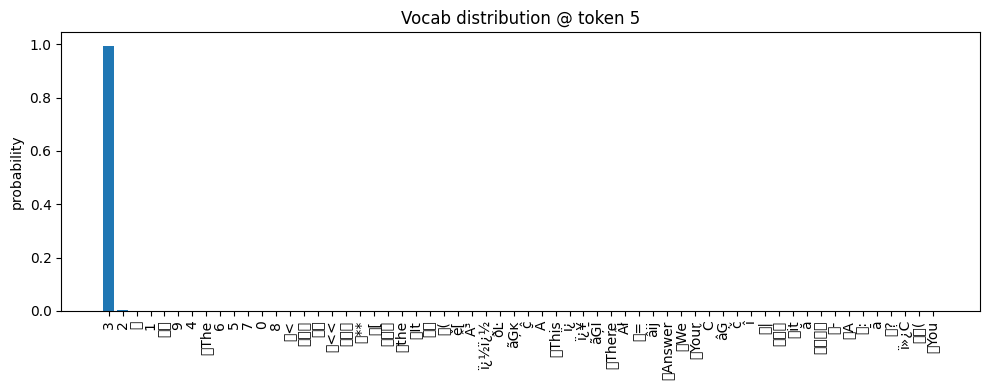

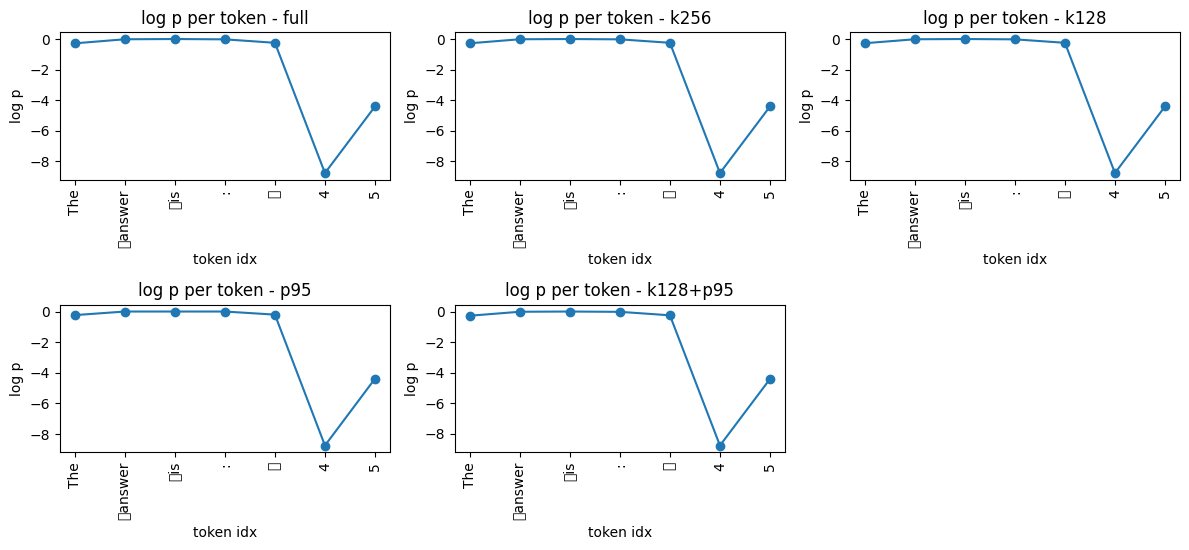

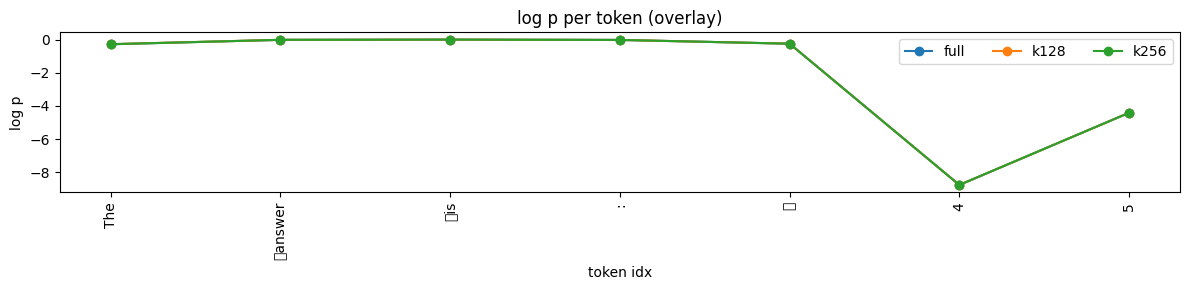

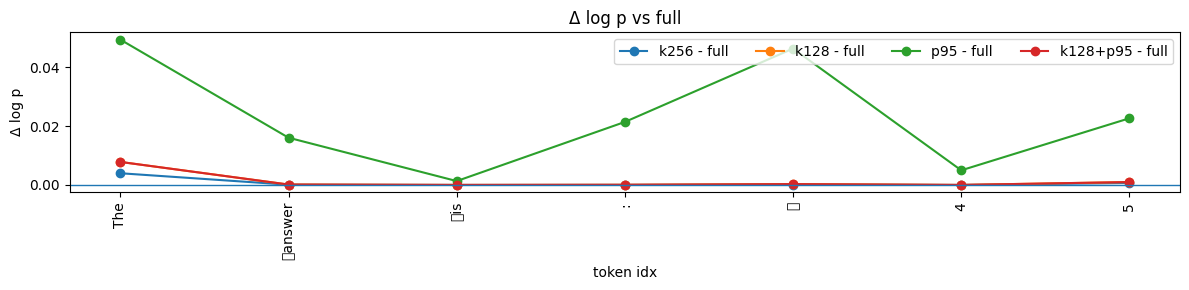

In [7]:
prompt = prompt_ctx["after_each_step"][-1]
target = rewarder._format_answer_target(example["gold_answer"])
configs = [
    {"name":"full","top_k":None,"top_p":None},
    {"name":"k256","top_k":256,"top_p":None},
    {"name":"k128","top_k":128,"top_p":None},
    {"name":"p95","top_k":None,"top_p":0.95},
    {"name":"k128+p95","top_k":128,"top_p":0.95},
]

res = analyze_target_under_configs(rewarder, prompt, target, configs, p_cap_k=None)  # 정확 top-p
# print({k: (v["logp_mean"], v["avg_support"]) for k,v in res.items() if k not in ("token_ids","token_str","_row_logits_cache")})
# plot_logp_sweep(res)
plot_vocab_support(rewarder, prompt, target, token_idx=5, max_tokens=60, include_target=True)
plot_all_configs_with_labels(res)                      # 각 config를 개별 subplot으로
plot_overlay_configs(res, names=["full","k128", "k256"]) # 한 그림에 겹쳐 보기
plot_delta_vs_full(res, ref_name="full")  

configs = [
    {"name":"full","top_k":None,"top_p":None},
    {"name":"k256","top_k":256,"top_p":None},
    {"name":"k128","top_k":128,"top_p":None},
    {"name":"p95","top_k":None,"top_p":0.95},
    {"name":"k128+p95","top_k":128,"top_p":0.95},
]
sweep = sweep_step_rewards_by_trunc(
    rewarder,
    example["question"],
    example["steps"],
    example["gold_answer"],
    configs,
    neg_targets=neg_debug["final"],
    template_ids=[0,1,2,3],
    batch_size=6,
    normalize=True,
)
df = stack_step_reward_table(sweep)
print(df.head())

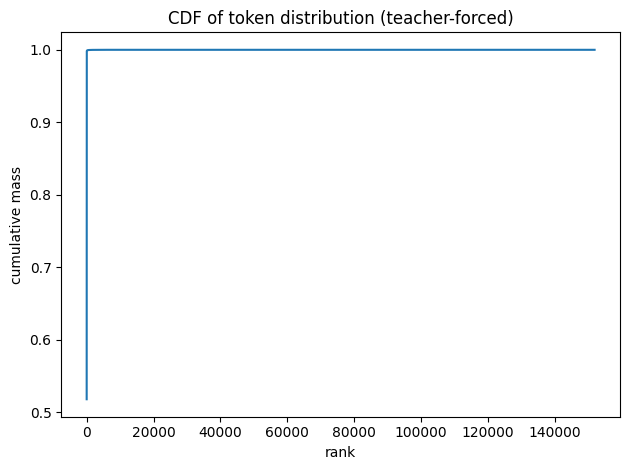

In [15]:
def plot_vocab_cdf_for_token(rewarder, prompt: str, target: str, pos: int = -2):
    """
    pos: target 내에서 볼 토큰 위치 (기본: 마지막 토큰).
    """
    import matplotlib.pyplot as plt
    tok = rewarder.tokenizer; dev = rewarder.device; model = rewarder.model
    with torch.no_grad():
        full = prompt + target
        enc = tok(full, return_tensors="pt", add_special_tokens=True)
        enc = {k:v.to(dev) for k,v in enc.items()}
        logits = model(**enc).logits.float()
    tgt_ids = tok(target, add_special_tokens=False)["input_ids"]
    full_ids = enc["input_ids"][0].tolist()
    start = rewarder._find_suffix_start(full_ids, tgt_ids)
    if start < 0: start = len(full_ids) - len(tgt_ids)
    offset = max(start - 1, 0)
    eff_len = min(len(tgt_ids), logits.shape[1]-1 - offset)
    idx = eff_len-1 if pos < 0 else int(pos)
    row = logits[0, offset+idx, :]
    sorted_vals, _ = torch.sort(row, descending=True)
    probs = torch.softmax(sorted_vals, dim=-1).cpu().numpy()
    import numpy as np
    cdf = np.cumsum(probs)
    plt.figure()
    plt.plot(cdf)
    plt.xlabel("rank")
    plt.ylabel("cumulative mass")
    plt.title("CDF of token distribution (teacher-forced)")
    plt.tight_layout()

plot_vocab_cdf_for_token(rewarder, prompt, target, pos=-2)

# Merge PAV

In [2]:
import argparse, json, os, sys, re
from copy import deepcopy
from typing import Any, Dict, List, Tuple

def _load_records(path: str) -> List[Dict[str, Any]]:
    text = open(path, "r", encoding="utf-8").read().strip()
    if not text:
        return []
    if text[0] == "[":  # JSON array
        obj = json.loads(text)
        if not isinstance(obj, list):
            raise ValueError("Top-level JSON must be an array.")
        return obj
    # JSONL
    out = []
    for ln in text.splitlines():
        ln = ln.strip()
        if not ln:
            continue
        out.append(json.loads(ln))
    return out

_WS = re.compile(r"\s+")
def _norm(s: str) -> str:
    return _WS.sub(" ", s.strip())

def _comp_to_key(comp: Any) -> str:
    if isinstance(comp, list):
        return "|§|".join(_norm(str(x)) for x in comp)
    return _norm(str(comp))

def _make_key(rec: Dict[str, Any]) -> Tuple[str, str]:
    q = _norm(str(rec.get("question", "")))
    c = _comp_to_key(rec.get("completion", []))
    return (q, c)

def _save_jsonl(path: str, recs: List[Dict[str, Any]]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for r in recs:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def _eltwise_sum(a: List[float], b: List[float], alpha: float, strict: bool, key_info: str) -> List[float]:
    la, lb = len(a), len(b)
    if la != lb:
        if strict:
            raise ValueError(f"[strict_len] length mismatch {la}!={lb} for {key_info}")
        L = min(la, lb)
        if L == 0:
            return []
        sys.stderr.write(f"[warn] length mismatch {la}!={lb} for {key_info}; trimming to {L}\n")
        a, b = a[:L], b[:L]
    return [float(ax) + float(alpha)*float(bx) for ax, bx in zip(a, b)]

def main():
    A = _load_records("/home/leena/rs_prm/data/ms_cpmi_fin_qw3_4b.json")
    B = _load_records("/home/leena/rs_prm/data/ms_qval_qw3_4b.json")
    outp = "/home/leena/rs_prm/data/ms_pav_cpmi_marg_qw3_4b.json"
    reward_a_key = "pll_marginal_cont"  # (e.g., pll_marginal_cont / pll_cmi_cont / pll_loo_cont)
    reward_b_key = "base_reward"
    base_format = "A"
    alpha = 1
    strict_len = False

    # Build index for Type-B by (question, completion)
    bmap: Dict[Tuple[str,str], Dict[str, Any]] = {}
    for r in B:
        key = _make_key(r)
        bmap[key] = r

    out: List[Dict[str, Any]] = []
    n_match = n_skip = 0
    for ar in A:
        key = _make_key(ar)
        br = bmap.get(key)
        if br is None:
            n_skip += 1
            continue

        # pick structural base
        base = deepcopy(ar if base_format == "A" else br)

        # pull rewards
        if reward_a_key not in ar:
            sys.stderr.write(f"[skip] A missing key '{reward_a_key}' for {key}\n")
            n_skip += 1
            continue
        if reward_b_key not in br:
            sys.stderr.write(f"[skip] B missing key '{reward_b_key}' for {key}\n")
            n_skip += 1
            continue

        ra = ar[reward_a_key]
        rb = br[reward_b_key]
        if not isinstance(ra, list) or not isinstance(rb, list):
            sys.stderr.write(f"[skip] rewards not list for {key}\n")
            n_skip += 1
            continue

        try:
            rc = _eltwise_sum(ra, rb, alpha, strict_len, key_info=f"{reward_a_key}+{reward_b_key}")
        except ValueError as e:
            sys.stderr.write(f"[skip] {e}\n")
            n_skip += 1
            continue

        # attach results
        base["combined_reward"] = rc
        base["combine_meta"] = {
            "reward_a_key": reward_a_key,
            "reward_b_key": reward_b_key,
            "alpha": alpha,
            "matched_on": "question+completion",
            "lengths": {"A": len(ra), "B": len(rb), "C": len(rc)},
        }
        # (선택) 원본들도 남기고 싶다면:
        # base[f"{args.reward_a_key}__orig_A"] = ra
        # base[f"{args.reward_b_key}__orig_B"] = rb

        out.append(base)
        n_match += 1

    os.makedirs(os.path.dirname(outp) or ".", exist_ok=True)
    _save_jsonl(outp, out)

    print(f"[done] matched={n_match}  skipped={n_skip}  wrote={len(out)} -> {outp}")

if __name__ == "__main__":
    main()


[done] matched=80000  skipped=0  wrote=80000 -> /home/leena/rs_prm/data/ms_pav_cpmi_marg_qw3_4b.json


# 기타

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

CACHE = "/data/hub"   # 원하는 경로
model_id = "Qwen/Qwen3-8B-Base"

tok = AutoTokenizer.from_pretrained(model_id, cache_dir=CACHE, trust_remote_code=True)
mdl = AutoModelForCausalLM.from_pretrained(model_id, cache_dir=CACHE, trust_remote_code=True)
